# Cars 4 You: Expediting Car Evaluations with ML
### Data Import & Exploratory Data Analysis



#### **Importing the Libraries**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### **Importing the Dataset**

In [3]:
train= pd.read_csv("train.csv").copy() #importing the dataset
test=pd.read_csv("test.csv").copy()


#### **Inspeção Inicial**

In [4]:
#numero de linhas e colunas
print(train.shape) 

(75973, 14)


In [5]:
display(train.head())

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


In [6]:
display(train.info()) # to see the data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


None

In [7]:
#definir as colunas como categoricas, numericas etc 
categorical_columns = train.select_dtypes(include=['object']).columns
numerical_columns = train.select_dtypes(include=['int64', 'float64']).columns
categorical_columns, numerical_columns

#futuramente fará sentido alterar o tipo de algumas colunas, como por exemplo year 

(Index(['Brand', 'model', 'transmission', 'fuelType'], dtype='object'),
 Index(['carID', 'year', 'price', 'mileage', 'tax', 'mpg', 'engineSize',
        'paintQuality%', 'previousOwners', 'hasDamage'],
       dtype='object'))

In [ ]:
# Ao imprimir o inicio da tabela ja conseguimos perceber que temos missing values nomeadamente na coluna tax, e que temos inconsistências nas valores da variavel transmission por exemplo.
# No que toca a tipos de dados, as colunas year e previousOwners aparecem como float64 por causa dos missing values. Após imputação, serão convertidas para inteiros, uma vez que não fazem sentido como valores decimais. hasDamage será convertida para binária (0/1) para facilitar o encoding.
#falar do tipo de cada variavel, se é continua, categórica, ordinal, binária (?)

#### **Inicio do processo para corrigir as variaveis categoricas 

In [8]:
#vamos imprimir os valores únicos de cada coluna categórica para percebermos se existem inconsistências
for col in categorical_columns:
    unique_values = train[col].unique()
    print(f"Column: {col}, Unique Values: {unique_values}")

Column: Brand, Unique Values: ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'FOR'
 'mercedes' 'Hyundai' 'w' 'ord' 'MW' 'bmw' nan 'yundai' 'BM' 'Toyot' 'udi'
 'Ope' 'AUDI' 'V' 'opel' 'pel' 'For' 'pe' 'Mercede' 'audi' 'MERCEDES'
 'OPEL' 'koda' 'FORD' 'Hyunda' 'W' 'Aud' 'vw' 'hyundai' 'skoda' 'ford'
 'TOYOTA' 'ercedes' 'oyota' 'toyota' 'SKODA' 'Skod' 'HYUNDAI' 'kod' 'v'
 'for' 'SKOD' 'aud' 'KODA' 'PEL' 'yunda' 'or' 'UDI' 'OYOTA' 'HYUNDA' 'mw'
 'OPE' 'mercede' 'ERCEDES' 'ercede' 'TOYOT' 'MERCEDE' 'ORD' 'ud' 'ope'
 'AUD' 'hyunda' 'skod' 'toyot']
Column: model, Unique Values: [' Golf' ' Yaris' ' Q2' ' FIESTA' ' 2 Series' '3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Clas' ' Q3' ' Fabia' ' A Class' ' Ka+'
 ' 3 Series' ' GLC Class' ' I30' ' C Class' ' Polo' ' E Class' ' C Clas'
 ' Q5' ' Up' ' Fiesta' ' C-HR' ' Mokka X' ' Corsa' ' Astra' ' TT'
 ' 5 Series' ' Aygo' ' 4 Series' ' SLK' ' Viva' ' T-Roc' 'Focus'
 ' EcoSport' ' Tucson' ' EcoSpor' nan ' X-CLASS' ' CL C

In [13]:
#conseguimos perceber que há inconsistencias em todas as colunas categóricas
#começamos por passar todas as colunas categoricas para upper case e retirar os espaços em branco do inicio e fim da string
for column in categorical_columns:
    train[column] = train[column].str.upper().str.strip()  
    print(f"Unique values in column '{column}' after stripping and uppercasing: {train[column].unique()}") 


Unique values in column 'Brand' after stripping and uppercasing: ['VW' 'TOYOTA' 'AUDI' 'FORD' 'BMW' 'SKODA' 'OPEL' 'MERCEDES' 'FOR'
 'HYUNDAI' 'W' 'ORD' 'MW' nan 'YUNDAI' 'BM' 'TOYOT' 'UDI' 'OPE' 'V' 'PEL'
 'PE' 'MERCEDE' 'KODA' 'HYUNDA' 'AUD' 'ERCEDES' 'OYOTA' 'SKOD' 'KOD'
 'YUNDA' 'OR' 'ERCEDE' 'UD']
Unique values in column 'model' after stripping and uppercasing: ['GOLF' 'YARIS' 'Q2' 'FIESTA' '2 SERIES' '3 SERIES' 'A3' 'OCTAVIA'
 'PASSAT' 'FOCUS' 'INSIGNIA' 'A CLAS' 'Q3' 'FABIA' 'A CLASS' 'KA+'
 'GLC CLASS' 'I30' 'C CLASS' 'POLO' 'E CLASS' 'C CLAS' 'Q5' 'UP' 'C-HR'
 'MOKKA X' 'CORSA' 'ASTRA' 'TT' '5 SERIES' 'AYGO' '4 SERIES' 'SLK' 'VIVA'
 'T-ROC' 'ECOSPORT' 'TUCSON' 'ECOSPOR' nan 'X-CLASS' 'CL CLASS' 'IX20'
 'I20' 'RAPID' 'A1' 'AURIS' 'SHARAN' 'ADAM' 'X3' 'A8' 'GLS CLASS' 'B-MAX'
 'A4' 'KONA' 'I10' 'MOKKA' 'S-MAX' 'X2' 'CROSSLAND X' 'TIGUAN' 'A5'
 'GLE CLASS' 'ZAFIRA' 'IONIQ' 'A6' 'MONDEO' 'YETI OUTDOOR' 'X1' 'SCALA'
 'S CLASS' '1 SERIES' 'KAMIQ' 'KUGA' 'TOURNEO CONNECT' 'Q7' 'GLA C

/var/folders/cw/5j_vwkz13qgb1l9c2f5cx6q80000gn/T/ipykernel_1633/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/cw/5j_vwkz13qgb1l9c2f5cx6q80000gn/T/ipykernel_1633/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/cw/5j_vwkz13qgb1l9c2f5cx6q80000gn/T/ipykernel_1633/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/cw/5j_vwkz13qgb1l9c2f5cx6q80000gn/T/ipykernel_1633/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

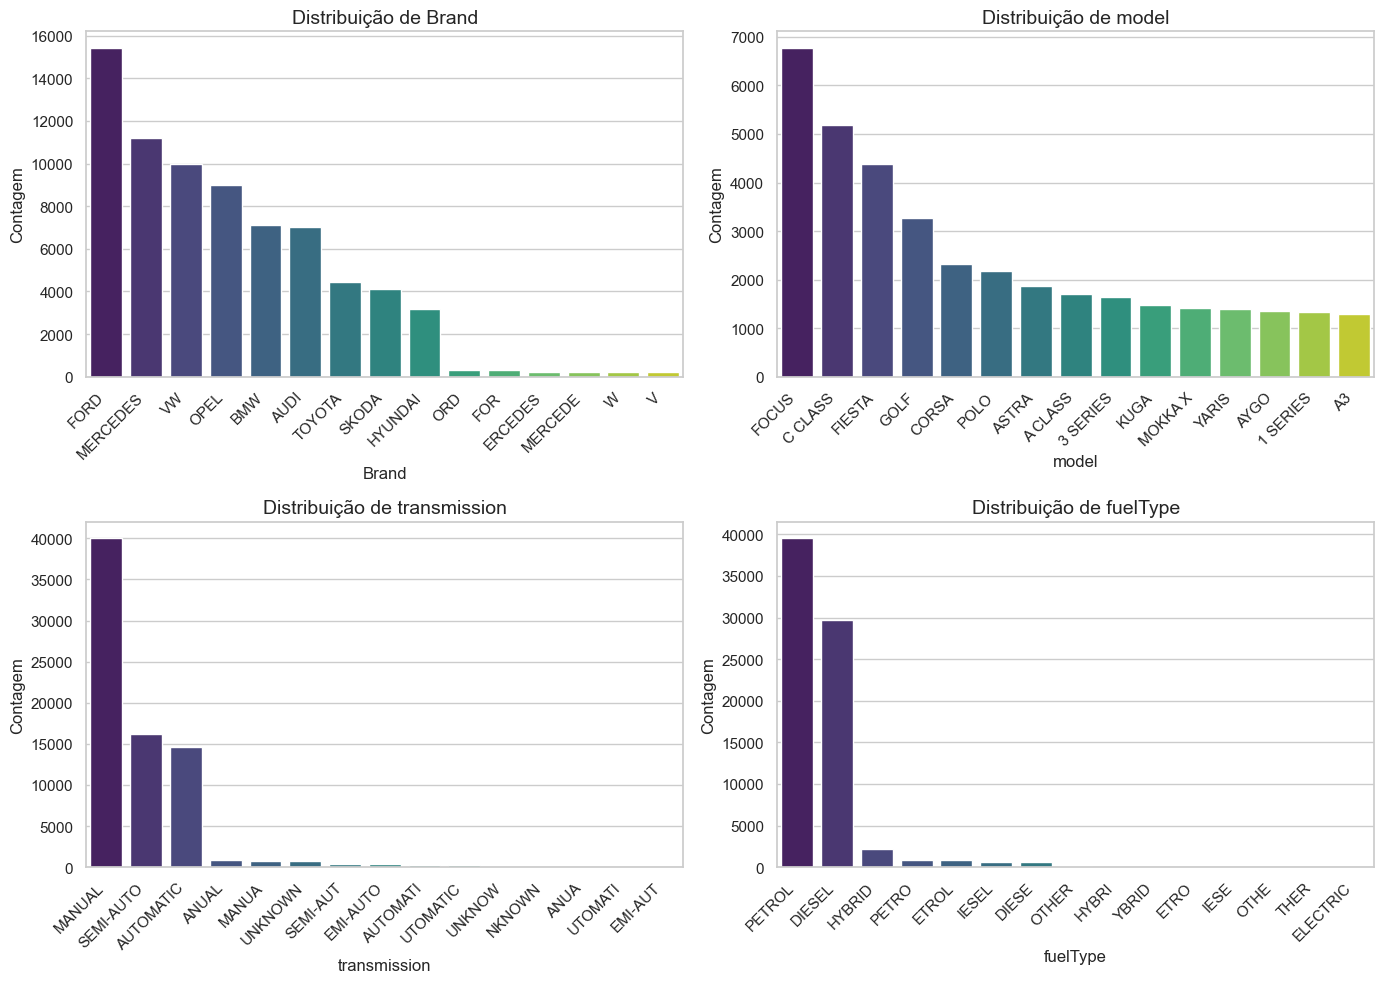

In [10]:
sns.set(style="whitegrid")

# Cria um subplot por variável
n_cols = 2
n_rows = (len(categorical_columns) + 1) // n_cols

plt.figure(figsize=(14, 5 * n_rows))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    
    # Mostra as 15 categorias mais comuns
    top_values = train[col].value_counts().head(15)
    
    sns.barplot(
        x=top_values.index,
        y=top_values.values,
        palette="viridis"
    )
    
    plt.title(f"Distribuição de {col}", fontsize=14)
    plt.ylabel("Contagem")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# o meu objetivo com estes graficos era perceber se existia a possibilidade de definir um threshold de frequencia para distinguir valores validos de invalidos
# so que nao funciona para os modelos claramente
# no entanto para as outras var alem do model acho que pode funcionar, so que por exemplo em fueltype tens o eletric que é valido so que como só tem uma amostra vai acabar por nao estar na lista dos validos, mas dá para resolver acho eu

In [ ]:
train['model'].value_counts()

model
FOCUS           6775
C CLASS         5194
FIESTA          4384
GOLF            3261
CORSA           2319
                ... 
URBAN CRUISE       1
6 SERIE            1
LAND CRUISE        1
VERS               1
TERRACAN           1
Name: count, Length: 296, dtype: int64

In [ ]:
#esta função eu acabei por perceber que não funciona porque por exemplo para o caso de UD que pode ser tanto audi como hyundai, e se eu substituir logo por audi ou hyundai (dependendo do que vai aparecer primeiro), depois quando chegar a hyundai ou audi ja nao vou conseguir perceber que é ambiguo

def normalize_by_containment(values):
    valores_unicos = [v for v in pd.Series(values).dropna().unique() if isinstance(v, str)]
    lista_limpa = []
    mapping = {}
    ambiguos = set()

    for v in valores_unicos:
        # procura valores já na lista que contenham ou sejam contidos por v
        candidatos = [x for x in lista_limpa if v in x or x in v]

        # se não há candidatos, adiciona
        if not candidatos:
            lista_limpa.append(v)
            mapping[v] = v
            continue

        # se há mais de um candidato, é ambíguo — não muda, mas regista
        if len(candidatos) > 1:
            mapping[v] = v
            ambiguos.add(v)
            continue

        # se há só um candidato
        c = candidatos[0]
        if v in c:
            # valor é substring do existente
            mapping[v] = c
        elif c in v:
            # valor é superstring — substitui o existente
            lista_limpa.remove(c)
            lista_limpa.append(v)
            # atualiza todos que apontavam para c
            for k in list(mapping.keys()):
                if mapping[k] == c:
                    mapping[k] = v
            mapping[v] = v
        else:
            mapping[v] = v  # fallback (não devia acontecer)

    valores_normalizados = [mapping.get(v, v) for v in values]
    return valores_normalizados, sorted(list(ambiguos))


ambiguous_summary = {}

for col in categorical_columns:
    print(f"\nNormalizando coluna: {col}")

    # aplica a função
    train[col], ambiguos = normalize_by_containment(train[col])

    # guarda os ambíguos encontrados (se houver)
    if ambiguos:
        ambiguous_summary[col] = ambiguos
        print(f" Valores ambíguos encontrados ({len(ambiguos)}): {ambiguos}")
    else:
        print(" Nenhum valor ambíguo encontrado.")




Normalizando coluna: Brand
 Valores ambíguos encontrados (1): ['W']

Normalizando coluna: model
 Valores ambíguos encontrados (18): ['A', 'ADA', 'CADDY', 'I', 'IQ', 'K', 'KA', 'M', 'Q', 'RAV', 'RS', 'S CLAS', 'SL', 'T', 'U', 'VERS', 'X', 'Z']

Normalizando coluna: transmission
 Nenhum valor ambíguo encontrado.

Normalizando coluna: fuelType
 Nenhum valor ambíguo encontrado.


In [ ]:
#ignorem esta função sou eu a pensar, mas aqui esta vai ser a função que vou usar para normalizar os valores depois de ter a lista dos valores válidos 


# aqui vou ter de criar uma lista so com velores que nao tem interseção e a partir daí começo a fazer as comparações
# ha aqui tambem um problema que é "etro" tambem esta em petrol e other com a função do contain... 
# é preciso mudar isto de modo a que, quando estamos a analisar um valor tambem sejam tidos em conta os valores que vêm a seguir para analise, porque por exemplo, UD pode estar para representar AUDI mas tambem Hyundai, nao sabemos de que forma os dados foram alterador, e para estar a prova de bala, preciso que nao se susbtituam logo valores sabendo que pode vir um nome a seguir que o torne ambiguo, faz sentido?


#o que quero fazer é, criar ua lista de todas os valores unicos que nao estao contidos uns nos outros
# a partir daí, das palavras que sobraraam ver as que estão contidas em apenas 1 palavra da lista inicial 
# se estiverem contidas em mais do que uma palavra, são ambiguas e não se alteram
#se estiveram contidas numa so palavra entao passam a ser a palavra em que estao contidas
#depois para as palavras que deram ambiguas, vou criar uma função que recebe a lista de ambiguos e uma coluna de suporte, isto é, para cada valor ambiguo, vamos verificar na coluna de suporte se ha mais iguais por exemplo; temos uma marca ambigua, vamos ver se na coluna model ha mais models iguais, se houver, então alteramos a marca para a marca que está na coluna model
# os que nao nao houver outro model assim, 


def normalize_by_containment(values):
    valores_unicos = [v for v in pd.Series(values).dropna().unique() if isinstance(v, str)]
    lista_limpa = []
    mapping = {}
    ambiguos = set()

    for v in valores_unicos:
        # procura valores já na lista que contenham ou sejam contidos por v
        candidatos = [x for x in lista_limpa if v in x or x in v]

        # se não há candidatos, adiciona
        if not candidatos:
            lista_limpa.append(v)
            mapping[v] = v
            continue

        # se há mais de um candidato, é ambíguo — não muda, mas regista
        if len(candidatos) > 1:
            mapping[v] = v
            ambiguos.add(v)
            continue

        # se há só um candidato
        c = candidatos[0]
        if v in c:
            # valor é substring do existente
            mapping[v] = c
        elif c in v:
            # valor é superstring — substitui o existente
            lista_limpa.remove(c)
            lista_limpa.append(v)
            # atualiza todos que apontavam para c
            for k in list(mapping.keys()):
                if mapping[k] == c:
                    mapping[k] = v
            mapping[v] = v
        else:
            mapping[v] = v  # fallback (não devia acontecer)

    valores_normalizados = [mapping.get(v, v) for v in values]
    return valores_normalizados, sorted(list(ambiguos))


In [ ]:
#normalizar os valores de cada coluna categórica
ambiguous_summary = {}

for col in categorical_columns:
    print(f"\n Coluna normalizada: {col}")

    train[col], ambiguos = normalize_by_containment(train[col])

    if ambiguos:
        ambiguous_summary[col] = ambiguos
        print(f" Valores ambíguos encontrados ({len(ambiguos)}): {ambiguos}")
    else:
        print(" Nenhum valor ambíguo encontrado.")
  


 Coluna normalizada: Brand
 Valores ambíguos encontrados (7): ['ERCEDE', 'KOD', 'OR', 'PE', 'UD', 'W', 'YUNDA']

 Coluna normalizada: model
 Valores ambíguos encontrados (43): ['A', 'A CLAS', 'A CLASS', 'ADA', 'B CLAS', 'C CLAS', 'C CLASS', 'C-MA', 'CADDY', 'CADDY MAXI', 'CC', 'E CLAS', 'GOL', 'GOLF', 'I', 'I8', 'IQ', 'K', 'KA', 'M', 'MOKK', 'Q', 'RAV', 'RS', 'S CLAS', 'S CLASS', 'SL', 'T', 'TIGUA', 'TIGUAN', 'TT', 'U', 'UP', 'VERS', 'VERSO', 'VIV', 'X', 'X2', 'YET', 'YETI', 'Z', 'ZAFIR', 'ZAFIRA']

 Coluna normalizada: transmission
 Valores ambíguos encontrados (4): ['ANUA', 'EMI-AUT', 'NKNOW', 'UTOMATI']

 Coluna normalizada: fuelType
 Valores ambíguos encontrados (3): ['ETRO', 'IESE', 'YBRI']


#### **Missing Values**

In [12]:
#counting the number of duplicated rows
print(train.duplicated().sum()) #0 duplicated rows
#porque seria importante?

0


In [ ]:
#contagem de missing values por coluna e qual a percentagem 
missing_values = train.isnull().sum()
missing_percentage = (train.isnull().sum() / len(train)) * 100
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print(missing_data)
#lots of missing values in all the colums except the carID and price

                Missing Values  Percentage
carID                        0    0.000000
Brand                     1521    2.002027
model                     1517    1.996762
year                      1491    1.962539
price                        0    0.000000
transmission              1522    2.003343
mileage                   1463    1.925684
fuelType                  1511    1.988864
tax                       7904   10.403696
mpg                       7926   10.432654
engineSize                1516    1.995446
paintQuality%             1524    2.005976
previousOwners            1550    2.040198
hasDamage                 1548    2.037566


In [ ]:
# temos duas categorias principais de missing values, de 2% e de 10% de missing values 
# as com percentagem de missing values de 2% penso que nao consistem numa percentagem de missing values significativa 
# vamos analisar a distribuicao dos dados para perceber que abordagem faz mais sentido
# analisar garficos para perceber o que fazer com os missing values 


<Axes: >

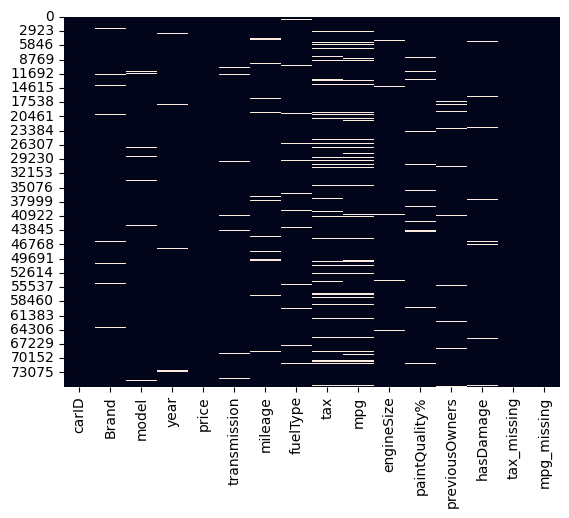

In [58]:
sns.heatmap(train.isna(), cbar=False)

In [ ]:
# Com este gráfico podemos reparar que quase todos os missing values de tax e mpg que são as variaveis que têm % de missing values mais significativa, estão juntos, isto faz sentido uma vez que carros eletricos ou hibridos(aqui nao sei se se aplica), nao têm mpg e estao muitas vezes isentos de taxas

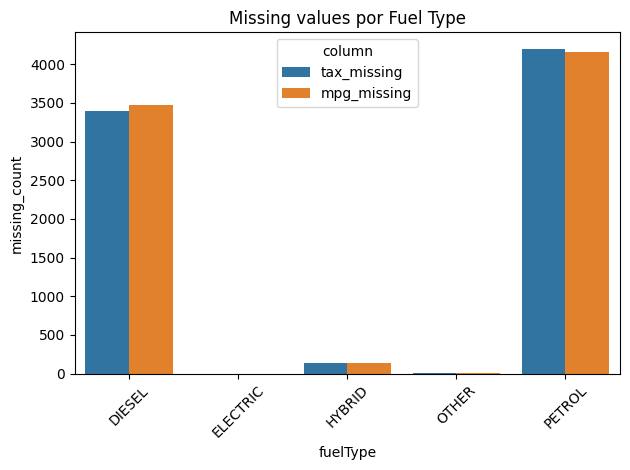

In [9]:
train['tax_missing'] = train['tax'].isna()
train['mpg_missing'] = train['mpg'].isna()

missing_counts = train.groupby('fuelType')[['tax_missing', 'mpg_missing']].sum().reset_index()
missing_melted = missing_counts.melt(id_vars='fuelType', var_name='column', value_name='missing_count')


sns.barplot(data=missing_melted, x='fuelType', y='missing_count', hue='column')
plt.title('Missing values por Fuel Type')
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()



In [ ]:
# fiz este grafico para tentar provar o meu ponto anterior e o grafico provou me exatamente o contrario, giro

## Alguns graficos e estatisticas que podem fazer sentido (não acabei)

In [19]:
#calculate some basic statistics for numerical columns
display(train.describe())

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


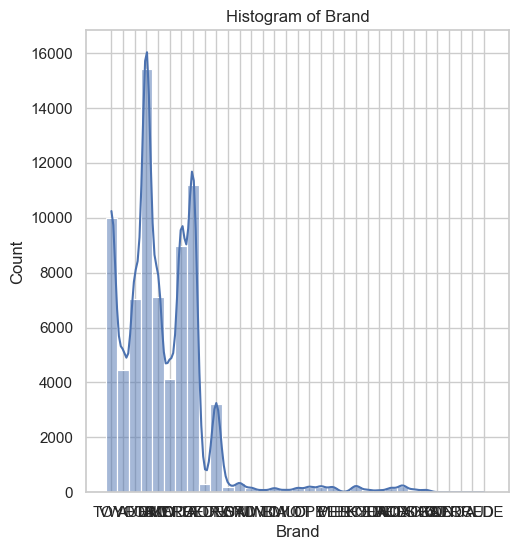

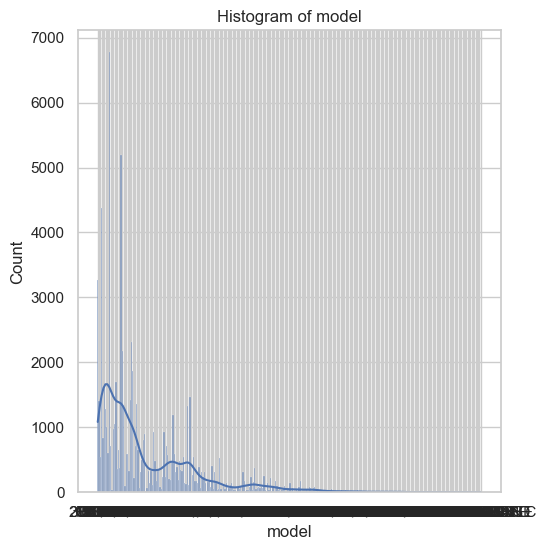

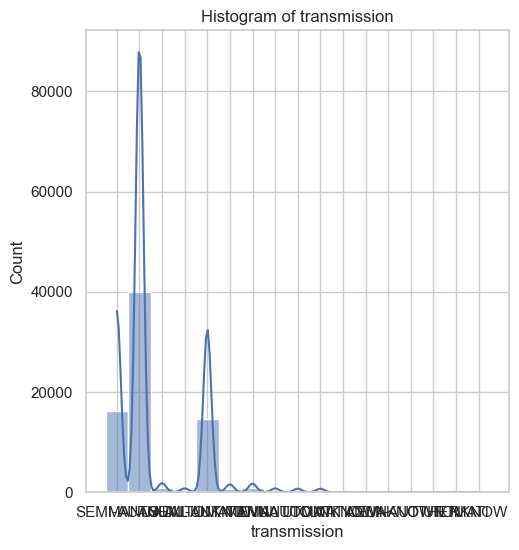

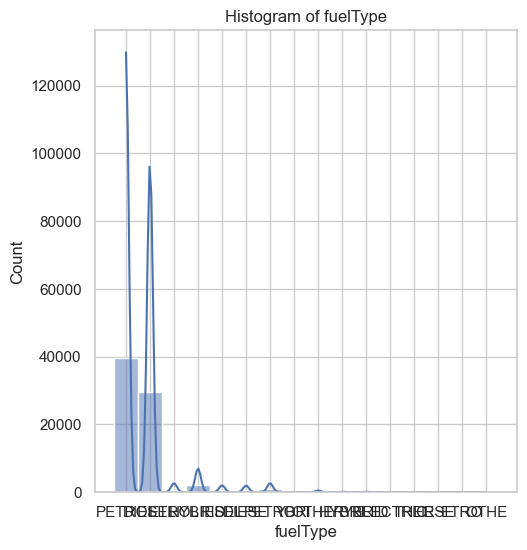

In [22]:
#Create graphics for numerical columns(histograms, boxplots, scatter plots)
numerical_columns = train.select_dtypes(include=[np.number]).columns.tolist()
for column in categorical_columns:
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    sns.histplot(train[column].dropna(), kde=True)
    plt.title(f'Histogram of {column}')
    
    plt.show()

#fazer mais graficos e tirar boas conclusoes dos gráficos 
